# Stability Analysis — RQ2

Measures whether feature attribution rankings are consistent across experimental splits.
Three split types are evaluated:
- **§13 Temporal** — early vs late observation window
- **§14 Route subgroups** — top departure→destination pairs by volume
- **§15 Cross-offer** — L5B15 vs CLUG replication variant

For each split pair and explanation method (DT / SHAP / LIME), rankings are computed
independently on each sub-split and compared with Spearman ρ, Jaccard@5, and Jaccard@10.

**Run `05_surrogate_fit.ipynb` and `06_explanation.ipynb` for each variant first.**

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────
from pathlib import Path

PRIMARY_VARIANT      = "L5B15"
REPLICATION_VARIANTS = ["CLUG", "BookingDotCom", "Cartrawler"]   # add variants here as notebooks 05+06 are run for them

PROCESSED_DIR = Path("../data/processed")
ARTIFACT_DIR  = Path("../data/artifacts")
ADM_BINNING   = Path("../data/adm/data-Predictor-binning-snapshot.json")

LIME_SAMPLE    = 500   # instances sampled per split for LIME (feasibility)
LIME_N_SAMPLES = 200   # perturbations per LIME instance
MIN_ROUTE_OBS  = 400   # minimum observations to include a route subgroup (lowered
                       # from 500 after the modelTechnique=="0.0" filter halved
                       # row counts; the top-4 L5B15 routes have 425–505 obs each)
TOP_N_ROUTES   = 4     # number of top routes to analyse
TEMPORAL_SPLIT = "2026-04-27"   # median pxDecisionTime for L5B15

print(f"Primary variant : {PRIMARY_VARIANT}")
print(f"Replication     : {REPLICATION_VARIANTS}")
print(f"Temporal split  : {TEMPORAL_SPLIT}")

In [2]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor

sys.path.insert(0, "../src")
from my_project.explanation import (
    PegaBinEncoder,
    compute_split_rankings,
)
from my_project.features import PEGA_MODEL_IDS, VARIANT_FEATURES
from my_project.metrics import feature_ranking, jaccard_at_k, stability_row, stability_spearman
from my_project.parsing import load_pega_bins
from my_project.surrogate import build_feature_matrix

print("Imports OK")

Imports OK


In [ ]:
# ── Load full dataset and primary variant artifacts ────────────────────────
import json as _json
import pandas as _pd

_lug = _pd.read_parquet(PROCESSED_DIR / "luggage_email_outbound.parquet")
_tp_path = PROCESSED_DIR / "thirdparty_email_outbound.parquet"
df_raw = _pd.concat(
    [_lug, _pd.read_parquet(_tp_path)] if _tp_path.exists() else [_lug],
    ignore_index=True,
)
del _lug, _pd, _tp_path

# Restrict to the production-decision technique (label "0.0"). Every scoring
# event is evaluated by two parallel techniques; analysis is on the model
# that actually drives offer decisions, matching what 05_surrogate_fit
# fitted. See 03_eda §6.10.
df_raw = df_raw[df_raw["modelTechnique"] == "0.0"].reset_index(drop=True)

df_raw["pxDecisionTime"] = pd.to_datetime(df_raw["pxDecisionTime"], utc=True, errors="coerce")

df = df_raw[df_raw["pyName"] == PRIMARY_VARIANT].reset_index(drop=True)

cfg = VARIANT_FEATURES[PRIMARY_VARIANT]

# Use the EXACT training feature set + order saved by 05_surrogate_fit, not
# cfg.features. 05 drops features that are constant in the variant's slice;
# loading via cfg.features would add the dropped column back at the wrong
# position, misaligning the saved model's cat_feature_indices.
saved_feature_cols = _json.loads(
    (ARTIFACT_DIR / PRIMARY_VARIANT / "feature_cols.json").read_text()
)
X, y, cat_cols, num_cols = build_feature_matrix(df, saved_feature_cols, cfg.numeric)

# Metadata aligned with X (same row order as df)
meta = df[["pxDecisionTime",
           "CustBookedFlight.FlightData.DepartureAirport",
           "CustBookedFlight.FlightData.DestinationAirport"]].copy()
meta["route"] = meta["CustBookedFlight.FlightData.DepartureAirport"].astype(str) \
              + "->" \
              + meta["CustBookedFlight.FlightData.DestinationAirport"].astype(str)

# Global CatBoost surrogate
cb_model = CatBoostRegressor()
cb_model.load_model(str(ARTIFACT_DIR / PRIMARY_VARIANT / "catboost_model.cbm"))

# Background data for LIME (original train split)
train_idx  = np.load(ARTIFACT_DIR / PRIMARY_VARIANT / "train_idx.npy")
X_background = X.iloc[train_idx]

# Pega bin encoder for DT (loaded once, reused across all splits)
print("Loading Pega bins...")
pega_bins = load_pega_bins(ADM_BINNING, PEGA_MODEL_IDS[PRIMARY_VARIANT])
pega_enc  = PegaBinEncoder(pega_bins, cat_cols)
print(f"Pega bins loaded for {len(pega_bins)} predictors")

print(f"\nDataset: {len(df):,} rows  |  {X.shape[1]} features")
print(f"Date range: {meta['pxDecisionTime'].min().date()} → {meta['pxDecisionTime'].max().date()}")

## §13 Temporal Split Stability

The observation window is divided at the median `pxDecisionTime` into an early and late period.
Explanation rankings are computed independently on each half and compared.

In [4]:
split_date = pd.Timestamp(TEMPORAL_SPLIT, tz="UTC")

mask_early = meta["pxDecisionTime"] <= split_date
mask_late  = meta["pxDecisionTime"] >  split_date

X_early, y_early = X[mask_early], y[mask_early]
X_late,  y_late  = X[mask_late],  y[mask_late]

print(f"Temporal split at {TEMPORAL_SPLIT}")
print(f"  Early : {len(X_early):,} rows  "
      f"({meta.loc[mask_early, 'pxDecisionTime'].min().date()} → "
      f"{meta.loc[mask_early, 'pxDecisionTime'].max().date()})")
print(f"  Late  : {len(X_late):,} rows  "
      f"({meta.loc[mask_late, 'pxDecisionTime'].min().date()} → "
      f"{meta.loc[mask_late, 'pxDecisionTime'].max().date()})")

Temporal split at 2026-04-27
  Early : 31,010 rows  (2026-03-09 → 2026-04-26)
  Late  : 32,996 rows  (2026-04-27 → 2026-04-30)


In [5]:
print("Computing rankings for early split...")
rankings_early = compute_split_rankings(
    X_early, y_early, cb_model, X_background, cat_cols, num_cols, pega_enc,
    lime_sample=LIME_SAMPLE, lime_n_samples=LIME_N_SAMPLES,
)
print("Computing rankings for late split...")
rankings_late = compute_split_rankings(
    X_late, y_late, cb_model, X_background, cat_cols, num_cols, pega_enc,
    lime_sample=LIME_SAMPLE, lime_n_samples=LIME_N_SAMPLES,
)
print("Done.")

Computing rankings for early split...
Computing rankings for late split...
Done.


Temporal split stability:


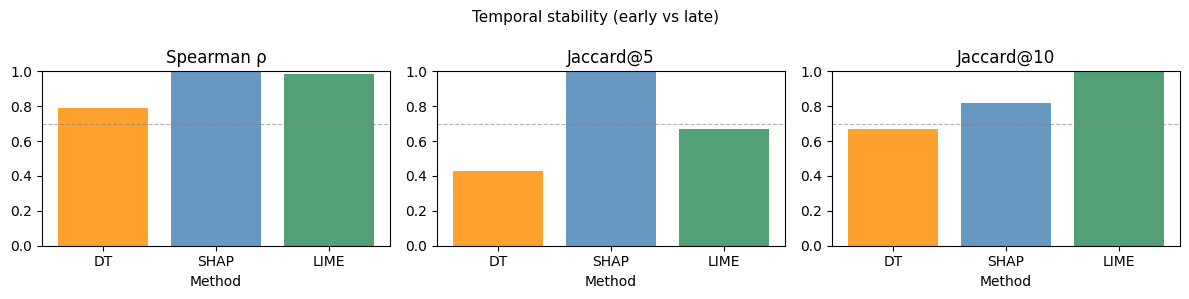

In [6]:
shared = list(X.columns)
temporal_rows = stability_row(
    rankings_early, rankings_late,
    label_a="early", label_b="late",
    n_a=len(X_early), n_b=len(X_late),
    shared_features=shared,
)
temporal_df = pd.DataFrame(temporal_rows)

print("Temporal split stability:")
display(
    temporal_df.set_index(["split", "method"])
    .style.format({"Spearman ρ": "{:.4f}", "Jaccard@5": "{:.4f}", "Jaccard@10": "{:.4f}"})
    .highlight_max(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#d4edda")
    .highlight_min(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#f8d7da")
)

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=False)
for ax, metric in zip(axes, ["Spearman ρ", "Jaccard@5", "Jaccard@10"]):
    ax.bar(temporal_df["method"], temporal_df[metric], color=["darkorange", "steelblue", "seagreen"], alpha=0.82)
    ax.set_ylim(0, 1)
    ax.set_title(metric)
    ax.axhline(0.7, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_xlabel("Method")
fig.suptitle("Temporal stability (early vs late)", fontsize=11)
plt.tight_layout()
plt.show()

## §14 Route Subgroup Stability

The top departure→destination routes by volume are identified (minimum `MIN_ROUTE_OBS` observations).
Rankings are computed independently for each route subgroup and compared pairwise.

In [7]:
route_counts = meta["route"].value_counts()
top_routes = route_counts[route_counts >= MIN_ROUTE_OBS].head(TOP_N_ROUTES)

print(f"Top {TOP_N_ROUTES} routes (>= {MIN_ROUTE_OBS} obs):")
print(top_routes.to_string())

route_subsets = {}
for route in top_routes.index:
    mask = meta["route"] == route
    route_subsets[route] = (X[mask], y[mask])

Top 4 routes (>= 500 obs):
route
ORY->NCE    1008
ORY->OPO     967
NCE->ORY     913
TLS->ORY     849


In [8]:
route_rankings = {}
for route, (X_r, y_r) in route_subsets.items():
    print(f"Computing rankings for {route} (n={len(X_r):,})...")
    route_rankings[route] = compute_split_rankings(
        X_r, y_r, cb_model, X_background, cat_cols, num_cols, pega_enc,
        lime_sample=min(LIME_SAMPLE, len(X_r)),
        lime_n_samples=LIME_N_SAMPLES,
    )
print("Done.")

Computing rankings for ORY->NCE (n=1,008)...
Computing rankings for ORY->OPO (n=967)...
Computing rankings for NCE->ORY (n=913)...
Computing rankings for TLS->ORY (n=849)...
Done.


In [9]:
route_list = list(route_rankings.keys())
route_rows = []

# Compare each adjacent pair (route_1 vs route_2, route_2 vs route_3, ...)
for i in range(len(route_list) - 1):
    r1, r2 = route_list[i], route_list[i + 1]
    route_rows.extend(stability_row(
        route_rankings[r1], route_rankings[r2],
        label_a=r1, label_b=r2,
        n_a=len(route_subsets[r1][0]),
        n_b=len(route_subsets[r2][0]),
        shared_features=shared,
    ))

route_df = pd.DataFrame(route_rows)
print("Route subgroup stability:")
display(
    route_df.set_index(["split", "method"])
    .style.format({"Spearman ρ": "{:.4f}", "Jaccard@5": "{:.4f}", "Jaccard@10": "{:.4f}"})
    .highlight_max(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#d4edda")
    .highlight_min(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#f8d7da")
)

Route subgroup stability:


In [10]:
# ── §14b  Route temporal overlap + DT within-route stability bootstrap ─────
# Two checks that validate the controlled-experiment interpretation:
#   1. Routes share the same observation window (delta_m ~ 0 by design)
#   2. Within-route DT rho >> between-route DT rho -> instability is genuine signal

from my_project.explanation import dt_surrogate, dt_importances

# ── Part 1: date ranges ───────────────────────────────────────────────────
print("Route subgroup date ranges (confirms shared time window):")
all_mins, all_maxs = [], []
for route, (X_r, y_r) in route_subsets.items():
    mask = meta["route"] == route
    dt_min = meta.loc[mask, "pxDecisionTime"].min()
    dt_max = meta.loc[mask, "pxDecisionTime"].max()
    all_mins.append(dt_min)
    all_maxs.append(dt_max)
    print(f"  {route:22s}  n={len(X_r):,}  {dt_min.date()} -> {dt_max.date()}")

overlap_start = max(all_mins).date()
overlap_end   = min(all_maxs).date()
print()
print(f"  Shared overlap window: {overlap_start} -> {overlap_end}")
print("  All routes share the full observation window -- same model snapshots active.")

# ── Part 2: within-route DT bootstrap ─────────────────────────────────────
# Re-fit DT N_BOOTS times on the same route data with different random seeds.
# Mean within-route rho_DT = DT baseline reproducibility on identical data.
# If within-route rho >> between-route rho, the between-route gap is genuine.

N_BOOTS = 10
between_rhos = [r["Spearman ρ"] for r in route_rows if r["method"] == "DT"]
mean_between = float(np.mean(between_rhos))

print()
print(f"Within-route DT bootstrap  (N={N_BOOTS} seeds):")
within_results = {}
for route, (X_r, y_r) in route_subsets.items():
    imps = []
    for seed in range(N_BOOTS):
        dt, _, _, _ = dt_surrogate(
            X_r, y_r, cat_cols, num_cols,
            max_depth_range=range(1, 9), n_splits=5,
            encoder=pega_enc, random_state=seed,
        )
        imps.append(dt_importances(dt, list(X_r.columns)))
    pair_rhos = [
        stability_spearman(feature_ranking(imps[i]), feature_ranking(imps[j]))
        for i in range(N_BOOTS) for j in range(i + 1, N_BOOTS)
    ]
    within_results[route] = float(np.mean(pair_rhos))
    print(f"  {route:22s}  within-route mean rho_DT = {within_results[route]:.4f}")

mean_within = float(np.mean(list(within_results.values())))
gap = mean_within - mean_between

print()
print(f"  Mean within-route rho_DT  : {mean_within:.4f}  (DT reproducibility on same data)")
print(f"  Mean between-route rho_DT : {mean_between:.4f}  (from stability table above)")
print(f"  Gap (within - between)    : {gap:+.4f}")
print()
if gap > 0.10:
    print("  CONCLUSION: gap > 0.10 -- between-route instability is genuine signal,")
    print("  not DT fitting noise. The route split result is valid.")
else:
    print("  WARNING: gap <= 0.10 -- between-route instability may partly reflect")
    print("  DT fitting variance rather than genuine explainer sensitivity.")

Route subgroup date ranges (confirms shared time window):
  ORY->NCE                n=1,008  2026-03-28 -> 2026-04-30
  ORY->OPO                n=967  2026-03-29 -> 2026-04-30
  NCE->ORY                n=913  2026-03-30 -> 2026-04-30
  TLS->ORY                n=849  2026-04-02 -> 2026-04-30

  Shared overlap window: 2026-04-02 -> 2026-04-30
  All routes share the full observation window -- same model snapshots active.

Within-route DT bootstrap  (N=10 seeds):
  ORY->NCE                within-route mean rho_DT = 0.9311
  ORY->OPO                within-route mean rho_DT = 0.6979
  NCE->ORY                within-route mean rho_DT = 0.8283
  TLS->ORY                within-route mean rho_DT = 0.7727

  Mean within-route rho_DT  : 0.8075  (DT reproducibility on same data)
  Mean between-route rho_DT : 0.6256  (from stability table above)
  Gap (within - between)    : +0.1819

  CONCLUSION: gap > 0.10 -- between-route instability is genuine signal,
  not DT fitting noise. The route split resu

## §14c Culture Subgroup Stability

A second natural experiment using `CultureCode` (fr-FR vs nl-NL) as the grouping variable. Both groups are observed within the same time window as the route splits, so model snapshots are shared and δ_m ≈ 0. Different nationalities have different booking behaviours and IH patterns, providing a compositionally distinct subgroup split without temporal confounding.

In [11]:
# ── Culture subgroup split (fr-FR vs nl-NL) ──────────────────────────────
CULTURE_CODES = ["fr-FR", "nl-NL"]
culture_col   = "CustBookedFlight.BookingData.CultureCode"

culture_subsets = {}
for code in CULTURE_CODES:
    mask = df[culture_col] == code
    culture_subsets[code] = (X[mask], y[mask])
    print(f"  {code}: n={mask.sum():,}")

  fr-FR: n=35,317
  nl-NL: n=11,437


In [12]:
# ── Compute rankings per culture group ────────────────────────────────────
culture_rankings = {}
for code, (X_c, y_c) in culture_subsets.items():
    print(f"Computing rankings for {code} (n={len(X_c):,})...")
    culture_rankings[code] = compute_split_rankings(
        X_c, y_c, cb_model, X_background, cat_cols, num_cols, pega_enc,
        lime_sample=min(LIME_SAMPLE, len(X_c)),
        lime_n_samples=LIME_N_SAMPLES,
    )
print("Done.")

Computing rankings for fr-FR (n=35,317)...
Computing rankings for nl-NL (n=11,437)...
Done.


In [13]:
# ── Culture stability table ───────────────────────────────────────────────
culture_rows = stability_row(
    culture_rankings["fr-FR"], culture_rankings["nl-NL"],
    label_a="fr-FR", label_b="nl-NL",
    n_a=len(culture_subsets["fr-FR"][0]),
    n_b=len(culture_subsets["nl-NL"][0]),
    shared_features=shared,
)

culture_df = pd.DataFrame(culture_rows)
print("Culture subgroup stability (fr-FR vs nl-NL):")
display(
    culture_df.set_index(["split", "method"])
    .style.format({"Spearman ρ": "{:.4f}", "Jaccard@5": "{:.4f}", "Jaccard@10": "{:.4f}"})
    .highlight_max(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#d4edda")
    .highlight_min(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#f8d7da")
)

Culture subgroup stability (fr-FR vs nl-NL):


## §15 Cross-offer Stability

Each replication variant is evaluated independently using its own feature space and surrogate.
Stability is measured within each variant (temporal split) and the pattern is compared
across variants to assess whether findings generalise beyond the primary L5B15 model.

**Requires:** notebooks 05 and 06 run for each variant in `REPLICATION_VARIANTS`.

In [ ]:
cross_results = {}   # variant -> temporal stability rows

for variant in REPLICATION_VARIANTS:
    artifact_path = ARTIFACT_DIR / variant
    required = ["catboost_model.cbm", "shap_importances.json", "dt_model.pkl",
                "feature_cols.json"]
    if not all((artifact_path / f).exists() for f in required):
        print(f"[SKIP] {variant}: explanation artifacts not yet generated — run 04+05 first.")
        continue

    print(f"Loading {variant}...")
    cfg_v = VARIANT_FEATURES[variant]
    df_v  = df_raw[df_raw["pyName"] == variant].reset_index(drop=True)

    # Same fix as primary loader: use saved training feature set + order so
    # the CatBoost model's cat_feature_indices align with X's columns.
    saved_feature_cols_v = _json.loads((artifact_path / "feature_cols.json").read_text())
    X_v, y_v, cat_v, num_v = build_feature_matrix(df_v, saved_feature_cols_v, cfg_v.numeric)

    meta_v  = df_v[["pxDecisionTime"]].copy()
    meta_v["pxDecisionTime"] = pd.to_datetime(meta_v["pxDecisionTime"], utc=True, errors="coerce")

    cb_v = CatBoostRegressor()
    cb_v.load_model(str(artifact_path / "catboost_model.cbm"))

    train_idx_v  = np.load(artifact_path / "train_idx.npy")
    X_bg_v       = X_v.iloc[train_idx_v]

    pega_bins_v  = load_pega_bins(ADM_BINNING, PEGA_MODEL_IDS[variant])
    pega_enc_v   = PegaBinEncoder(pega_bins_v, cat_v)

    # Temporal split at same relative midpoint
    split_v = meta_v["pxDecisionTime"].median()
    early_v = meta_v["pxDecisionTime"] <= split_v
    late_v  = ~early_v

    print(f"  {variant} temporal split at {split_v.date()}: "
          f"early={early_v.sum():,}  late={late_v.sum():,}")

    r_early = compute_split_rankings(
        X_v[early_v], y_v[early_v], cb_v, X_bg_v, cat_v, num_v, pega_enc_v,
        lime_sample=LIME_SAMPLE, lime_n_samples=LIME_N_SAMPLES,
    )
    r_late = compute_split_rankings(
        X_v[late_v], y_v[late_v], cb_v, X_bg_v, cat_v, num_v, pega_enc_v,
        lime_sample=LIME_SAMPLE, lime_n_samples=LIME_N_SAMPLES,
    )
    cross_results[variant] = stability_row(
        r_early, r_late,
        label_a="early", label_b="late",
        n_a=early_v.sum(), n_b=late_v.sum(),
        shared_features=list(X_v.columns),
    )
    print(f"  {variant} done.")

In [15]:
if cross_results:
    # Build a combined table: L5B15 temporal + each replication variant temporal
    all_cross_rows = temporal_rows.copy()
    for variant, rows in cross_results.items():
        for r in rows:
            r2 = r.copy()
            r2["split"] = f"{variant} early vs late"
            all_cross_rows.append(r2)

    cross_df = pd.DataFrame(all_cross_rows)[["split", "method", "Spearman ρ", "Jaccard@5", "Jaccard@10"]]
    print("Cross-offer temporal stability comparison:")
    display(
        cross_df.set_index(["split", "method"])
        .style.format("{:.4f}")
        .highlight_max(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#d4edda")
        .highlight_min(subset=["Spearman ρ", "Jaccard@5", "Jaccard@10"], color="#f8d7da")
    )
else:
    print("No replication variants ready yet — run notebooks 05+06 for CLUG and re-run this cell.")

Cross-offer temporal stability comparison:


## §16 Summary Stability Table

All splits × all methods in one table for the results chapter.

In [16]:
# rename primary temporal split label to match replication variant convention
all_rows = []
for r in temporal_rows:
    r2 = r.copy()
    r2["split"] = f"{PRIMARY_VARIANT} temporal"
    all_rows.append(r2)
all_rows += route_rows
all_rows += culture_rows
if cross_results:
    for variant, rows in cross_results.items():
        for r in rows:
            r2 = r.copy()
            r2["split"] = f"{variant} temporal"
            all_rows.append(r2)

summary_df = (
    pd.DataFrame(all_rows)[["split", "method", "Spearman ρ", "Jaccard@5", "Jaccard@10"]]
    .sort_values(["split", "method"])
)

print("Full stability summary:")
display(
    summary_df.set_index(["split", "method"])
    .style.format("{:.4f}")
    .background_gradient(subset=["Spearman ρ"], cmap="RdYlGn", vmin=0, vmax=1)
    .background_gradient(subset=["Jaccard@5", "Jaccard@10"], cmap="RdYlGn", vmin=0, vmax=1)
)

# Save
out_path = ARTIFACT_DIR / PRIMARY_VARIANT / "stability_summary.json"
summary_df.to_json(out_path, orient="records")
print(f"\nSaved to {out_path}")

Full stability summary:



Saved to ../data/artifacts/L5B15/stability_summary.json
